In [3]:
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
L = 10
temp = np.linspace(2.269, 5, 10)

In [ ]:
temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]
temp_n = [temp_n[0]]

output_dir = "Hamming_Distances_n"
os.makedirs(output_dir, exist_ok=True)

loaded_distances = []
for T in temp_n:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [19]:
temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]
new_distance = []
for i in range(len(temp_n)):
    new_distance.append(np.loadtxt(f"Hamming_Distances/new_distances_T_{temp_n[i]}.txt"))

In [27]:
dist_load10 = loaded_distances[-1]
nearest_dist = np.loadtxt(f"Hamming_Distances_n/new_distances_T_5.0.txt")
R_10 = np.mean(nearest_dist)
R_10

56.718266666666665

In [ ]:
modified_load10 = [np.insert(arr, i, 0) for i, arr in enumerate(dist_load10)]
modified_load10 = np.array(modified_load10)

In [53]:
bond_index = []
for i in range(len(modified_load10)):
    bond = []
    for j in range(len(modified_load10[i])):
        if i != j:
            if R_10 > modified_load10[i][j]:
                bond.append(j)
    bond_index.append(bond)

In [74]:
modified_load10

array([[  0.,  74.,  86., ...,  72.,  98., 114.],
       [ 74.,   0.,  68., ...,  82., 100., 100.],
       [ 86.,  68.,   0., ...,  90.,  96., 112.],
       ...,
       [ 72.,  82.,  90., ...,   0.,  70., 106.],
       [ 98., 100.,  96., ...,  70.,   0.,  88.],
       [114., 100., 112., ..., 106.,  88.,   0.]])

In [ ]:
bond_indexa = []
for i in range(len(modified_load10)):
    bonds = np.where((modified_load10[i] < R_10) & (np.arange(len(modified_load10[i])) != i))[0]
    bond_indexa.append(bonds.tolist())

In [61]:
bond_indexa == bond_index

True

In [68]:
graph = nx.Graph()

for node, neighbors in enumerate(bond_index):
    for neighbor in neighbors:
        graph.add_edge(node, neighbor)

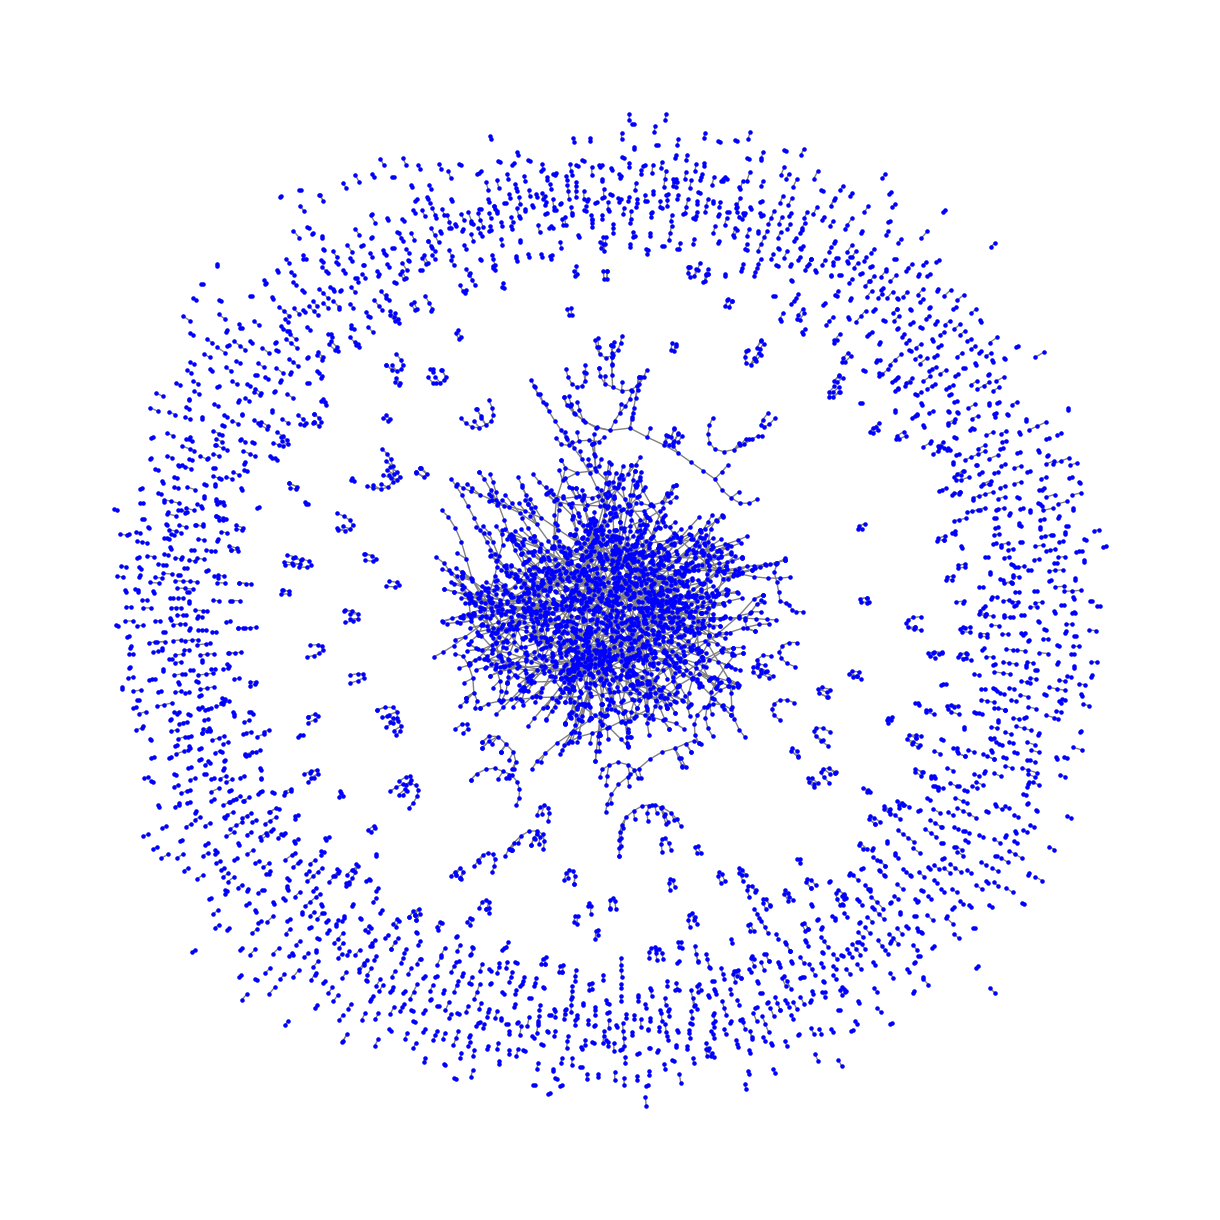

In [70]:
plt.figure(figsize=(12, 12))

pos = nx.spring_layout(graph, seed=42)  
nx.draw(graph, pos, node_size=5, edge_color='gray', node_color='blue', with_labels=False)
plt.show()

In [175]:
block_size = 25
row_start, col_start = 0, 0
block = modified_load10[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

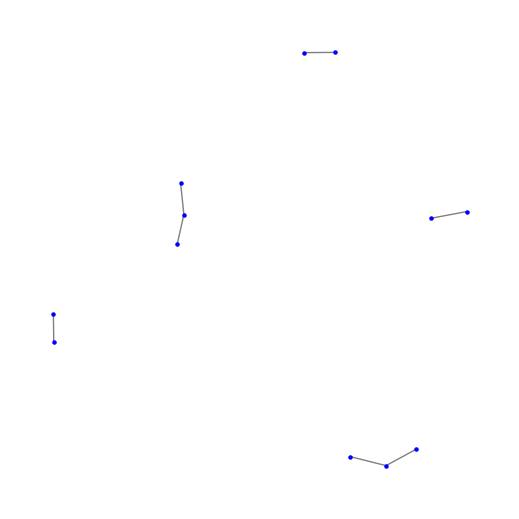

In [176]:
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=5, edge_color='gray', node_color='blue', with_labels=False)
plt.show()

# At Critical Point

In [122]:
temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]
temp_n = [temp_n[0]]

output_dir = "Hamming_Distances_n"
os.makedirs(output_dir, exist_ok=True)

loaded_distances = []
for T in temp_n:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [137]:
#dist_load1 = loaded_distances[0]
dist_load1 = loaded_distances[0][2650:3650]
dist_load1

array([[120., 120., 120., ..., 146., 144., 150.],
       [128., 128., 128., ..., 158., 152., 154.],
       [134., 130., 130., ..., 156., 154., 156.],
       ...,
       [106.,  94., 106., ..., 116., 118., 124.],
       [ 82.,  74.,  82., ...,  92.,  90., 100.],
       [ 78.,  74.,  74., ...,  84.,  78.,  88.]])

In [143]:
"ok"

'ok'

In [138]:
modified_load1 = [np.insert(arr, i, 0) for i, arr in enumerate(dist_load1)]
modified_load1 = np.array(modified_load1)

In [139]:
matrix = dist_load1
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)
mean_Rc

18.216

In [125]:
nearest_dist1 = np.loadtxt(f"Hamming_Distances_n/new_distances_T_{temp[0]}.txt")
R_1 = np.mean(nearest_dist1)
R_1

14.308133333333334

In [140]:
modified_load1

array([[  0., 120., 120., ..., 146., 144., 150.],
       [128.,   0., 128., ..., 158., 152., 154.],
       [134., 130.,   0., ..., 156., 154., 156.],
       ...,
       [106.,  94., 106., ..., 116., 118., 124.],
       [ 82.,  74.,  82., ...,  92.,  90., 100.],
       [ 78.,  74.,  74., ...,  84.,  78.,  88.]])

In [141]:
bond_indexa1 = []
for i in range(len(modified_load1)):
    bonds = np.where((modified_load1[i] < mean_Rc) & (np.arange(len(modified_load1[i])) != i))[0]
    bond_indexa1.append(bonds.tolist())

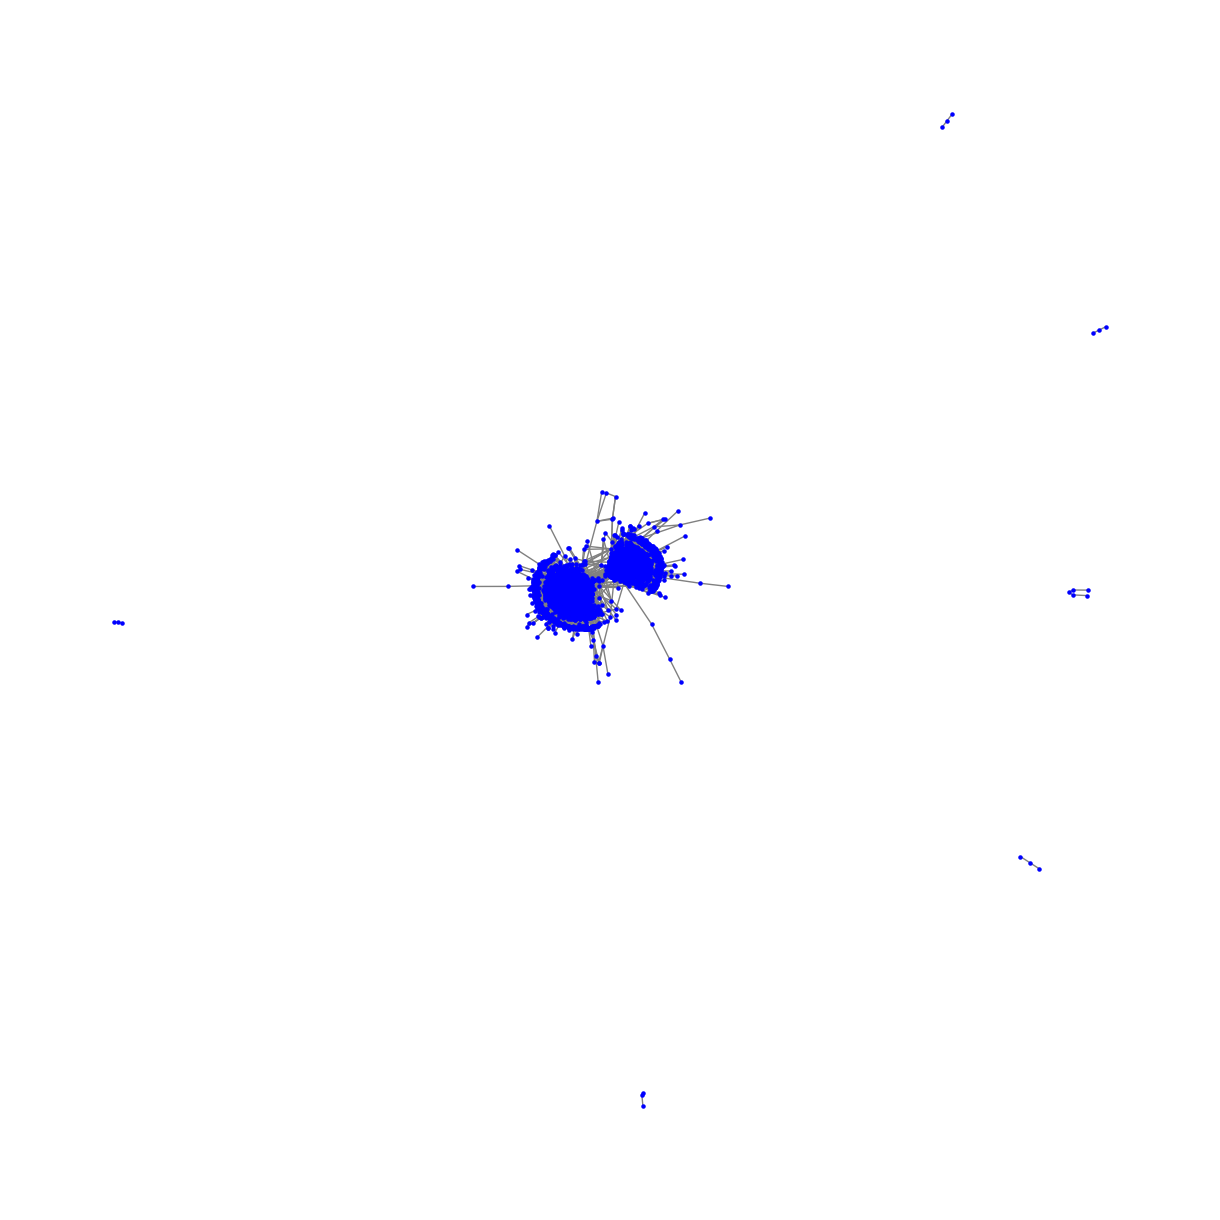

In [142]:
graph = nx.Graph()

for node, neighbors in enumerate(bond_indexa1):
    for neighbor in neighbors:
        graph.add_edge(node, neighbor)

plt.figure(figsize=(8, 8))

pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, node_size=5, edge_color='gray', node_color='blue', with_labels=False)
plt.show()

In [170]:
block_size = 300
row_start, col_start = 0, 0
block = modified_load1[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

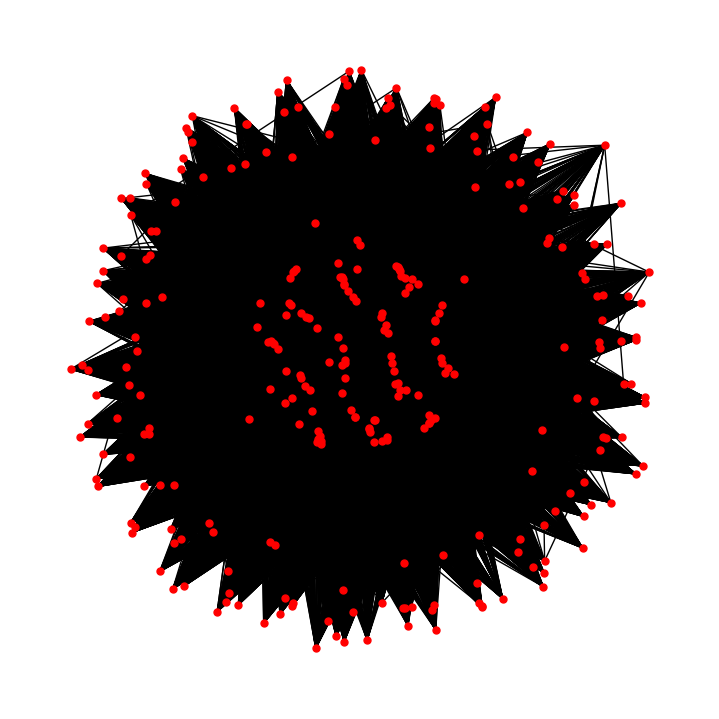

In [171]:
plt.figure(figsize=(7, 7))

pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=25, edge_color = "black", node_color='red', with_labels=False)
plt.show()

# Some other point other than critical temperature

In [177]:
temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]
temp_n = [temp_n[1]]

output_dir = "Hamming_Distances_n"
os.makedirs(output_dir, exist_ok=True)

loaded_distances = []
for T in temp_n:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [178]:
dist_load2 = loaded_distances[0]
dist_load2

array([[ 40.,  74.,  82., ..., 130., 134., 124.],
       [ 40.,  50.,  58., ..., 134., 126., 120.],
       [ 74.,  50.,  52., ..., 136., 132., 122.],
       ...,
       [130., 134., 136., ...,  48.,  52.,  66.],
       [134., 126., 132., ...,  80.,  52.,  34.],
       [124., 120., 122., ...,  90.,  66.,  34.]])

In [179]:
modified_load2 = [np.insert(arr, i, 0) for i, arr in enumerate(dist_load2)]
modified_load2 = np.array(modified_load2)

In [180]:
matrix = dist_load2
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)
mean_Rc

45.3016

In [182]:
nearest_dist1 = np.loadtxt(f"Hamming_Distances_n/new_distances_T_{temp_n[0]}.txt")
R_2 = np.mean(nearest_dist1)
R_2

45.3016

In [183]:
bond_indexa2 = []
for i in range(len(modified_load2)):
    bonds = np.where((modified_load2[i] < mean_Rc) & (np.arange(len(modified_load2[i])) != i))[0]
    bond_indexa2.append(bonds.tolist())

In [192]:
block_size = 10000
row_start, col_start = 0, 0
block = modified_load2[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

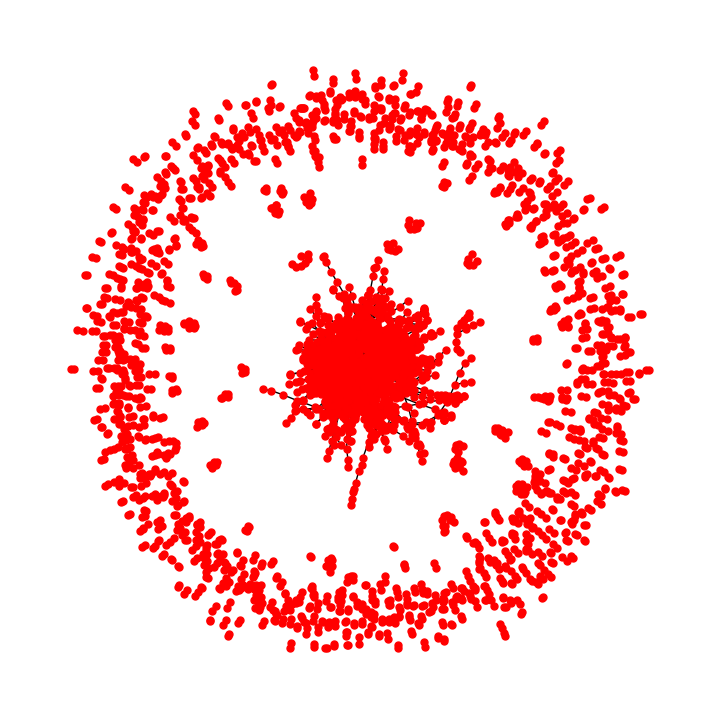

In [193]:
plt.figure(figsize=(7, 7))

pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=25, edge_color = "black", node_color='red', with_labels=False)
plt.show()